In [1]:
import json
import subprocess
import os
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import torch
from torch.utils.data import DataLoader, TensorDataset

# Resolve repository root from git
REPO_ROOT = Path(
    subprocess.check_output(["git", "rev-parse", "--show-toplevel"])  # nosec - local repo query
    .decode()
    .strip()
)
os.chdir(REPO_ROOT)
from models.wno.wno1d import WNO1d
from models.fno import count_params

DATA_DIR = REPO_ROOT / "data"
OUTPUTS_DIR = REPO_ROOT / "outputs"

# Plot styling
plt.rcParams["font.family"] = "DejaVu Serif"
title_font = {"family": "DejaVu Serif", "weight": "bold", "size": 12}

DEVICE = "cuda:0"
print(f"Repo root: {REPO_ROOT}")
print(f"Using device: {DEVICE}")

/home/johnma/dno-fno/.venv/lib64/python3.9/site-packages/pytorch_wavelets/dtcwt/coeffs.py:7: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import resource_stream


Repo root: /home/johnma/dno-fno
Using device: cuda:0


In [3]:
# --- User configuration ---
# Set the WNO run directory (outputs/run_wno_YYYYMMDD_HHMMSS)
RUN_DIR = OUTPUTS_DIR / "run_wno_20260205_040758"
#outputs/run_wno_20260205_040758/last_train.pt

# Dataset artifacts
DATASET_NAME = "stokes_dno_training_ichoi0.npz"

# Evaluation options
BATCH_SIZE = 64
TRAIN_PERCENT = 80.0
VAL_PERCENT = 10.0
TEST_PERCENT = 10.0
SEED = 0
NUM_WORKERS = 0

assert RUN_DIR.exists(), f"Run directory {RUN_DIR} not found"
assert (DATA_DIR / DATASET_NAME).exists(), "Dataset npz missing"
print(f"Evaluating run: {RUN_DIR}")

Evaluating run: /home/johnma/dno-fno/outputs/run_wno_20260205_040758


In [4]:
# Helper utilities mirroring train/1d_dno_wno.py

def load_run_config(run_dir: Path) -> dict:
    config_path = run_dir / "config.json"
    with open(config_path, "r", encoding="utf-8") as f:
        config = json.load(f)
    return config


def load_processed_dataset(npz_path: Path) -> dict:
    data = np.load(npz_path)
    required = {"eta", "xi", "Gxi"}
    missing = required - set(data.files)
    if missing:
        raise KeyError(f"Dataset {npz_path} missing keys: {missing}")
    return {key: data[key] for key in data.files}


def build_feature_target_tensors(dataset: dict) -> tuple[torch.Tensor, torch.Tensor]:
    eta = dataset["eta"][..., None]
    xi = dataset["xi"][..., None]
    inputs = np.concatenate([eta, xi], axis=-1)  # (N, Nx, 2)
    targets = dataset["Gxi"]
    return (
        torch.tensor(inputs, dtype=torch.float32),
        torch.tensor(targets, dtype=torch.float32),
    )


def split_indices(n_samples: int, train_pct: float, val_pct: float, test_pct: float):
    train_count = int(n_samples * (train_pct / 100.0))
    val_count = int(n_samples * (val_pct / 100.0))
    test_count = n_samples - train_count - val_count
    if train_count <= 0 or val_count <= 0 or test_count <= 0:
        raise ValueError("Each split must have at least one sample")
    train_idx = np.arange(0, train_count)
    val_idx = np.arange(train_count, train_count + val_count)
    test_idx = np.arange(train_count + val_count, train_count + val_count + test_count)
    return train_idx, val_idx, test_idx

In [5]:
# Load dataset + rebuild test split identical to training
npz_data = load_processed_dataset(DATA_DIR / DATASET_NAME)
features, targets = build_feature_target_tensors(npz_data)

train_idx, val_idx, test_idx = split_indices(
    len(features), TRAIN_PERCENT, VAL_PERCENT, TEST_PERCENT
)
print(f"Total samples: {len(features)} | Test count: {len(test_idx)}")

test_dataset = TensorDataset(
    features[test_idx],
    targets[test_idx],
)
test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
)

Total samples: 19992 | Test count: 2000


In [6]:
# Build plotting grid from dataset length
nx = features.shape[1]
x_plot = np.arange(nx)
print(f"Plotting grid size: {nx}")

Plotting grid size: 2048


In [7]:
# Load run configuration and rebuild WNO
config = load_run_config(RUN_DIR)
print("Loaded config:")
for k, v in config.items():
    print(f"  {k}: {v}")

state_path = RUN_DIR / "last_train.pt"
if not state_path.exists():
    state_path = RUN_DIR / "best_train.pt"
if not state_path.exists():
    raise FileNotFoundError(f"Missing checkpoint in {RUN_DIR}")
print(f"Model checkpoint: {state_path}")

model = WNO1d(
    width=config["width"],
    depth=config["depth"],
    J_blocks=config["J_blocks"],
).to(DEVICE)
state_dict = torch.load(state_path, map_location=DEVICE)
model.load_state_dict(state_dict)
model.eval()
print(f"Param count: {count_params(model):,}")

Loaded config:
  model: wno
  width: 256
  depth: 5
  J_blocks: 4
  batch_size: 64
  lr: 0.0005
  epochs: 300
  weight_decay: 1e-05
  param_count: 2928449
Model checkpoint: /home/johnma/dno-fno/outputs/run_wno_20260205_040758/last_train.pt
Param count: 2,928,449


In [8]:
# Evaluate on test set: collect predictions + per-sample relative errors
all_preds = []
rel_l2 = []
rel_l1 = []

with torch.no_grad():
    for x, y in test_loader:
        x = x.to(DEVICE)
        y = y.to(DEVICE)
        pred = model(x).squeeze(-1)

        all_preds.append(pred.cpu())

        flat_pred = pred.view(pred.size(0), -1)
        flat_true = y.view(y.size(0), -1)

        rel_l2.append(
            torch.norm(flat_pred - flat_true, dim=1) / (torch.norm(flat_true, dim=1) + 1e-12)
        )
        rel_l1.append(
            torch.sum(torch.abs(flat_pred - flat_true), dim=1)
            / (torch.sum(torch.abs(flat_true), dim=1) + 1e-12)
        )

predictions = torch.cat(all_preds, dim=0)
errors_l2 = torch.cat(rel_l2, dim=0)
errors_l1 = torch.cat(rel_l1, dim=0)

print("Test metrics:")
print(f"  Mean Rel L2: {errors_l2.mean().item():.6f}")
print(f"  Median Rel L2: {errors_l2.median().item():.6f}")
print(f"  Mean Rel L1: {errors_l1.mean().item():.6f}")
print(f"  Median Rel L1: {errors_l1.median().item():.6f}")

Test metrics:
  Mean Rel L2: 0.333630
  Median Rel L2: 0.252804
  Mean Rel L1: 0.298624
  Median Rel L1: 0.218653


In [9]:
# Summarize scalar metrics
summary = {
    "run_dir": str(RUN_DIR.relative_to(REPO_ROOT)),
    "param_count": count_params(model),
    "mean_rel_l2": errors_l2.mean().item(),
    "median_rel_l2": errors_l2.median().item(),
    "std_rel_l2": errors_l2.std().item(),
    "mean_rel_l1": errors_l1.mean().item(),
    "median_rel_l1": errors_l1.median().item(),
    "std_rel_l1": errors_l1.std().item(),
}
summary

{'run_dir': 'outputs/run_wno_20260205_040758',
 'param_count': 2928449,
 'mean_rel_l2': 0.3336299657821655,
 'median_rel_l2': 0.2528044283390045,
 'std_rel_l2': 0.207918182015419,
 'mean_rel_l1': 0.29862383008003235,
 'median_rel_l1': 0.2186528444290161,
 'std_rel_l1': 0.20385760068893433}

In [12]:
# Select representative samples
num_samples = len(predictions)
sorted_indices = torch.argsort(errors_l2)

sample_indices = {
    "best": sorted_indices[0].item(),
    "median": sorted_indices[num_samples // 2].item(),
    "worst": sorted_indices[-1].item(),
    "random": int(torch.randint(0, num_samples, (1,)).item()),
}

sample_indices

{'best': 880, 'median': 1364, 'worst': 1964, 'random': 1059}

In [13]:
# Prepare raw fields for plotting (eta, xi, Gxi) for test indices
eta_raw = torch.tensor(npz_data["eta"], dtype=torch.float32)[test_idx]
xi_raw = torch.tensor(npz_data["xi"], dtype=torch.float32)[test_idx]
Gxi_raw = torch.tensor(npz_data["Gxi"], dtype=torch.float32)[test_idx]

nx = eta_raw.shape[1]
x_plot = np.arange(nx)

print(f"Plotting grid size: {nx}")

Plotting grid size: 2048


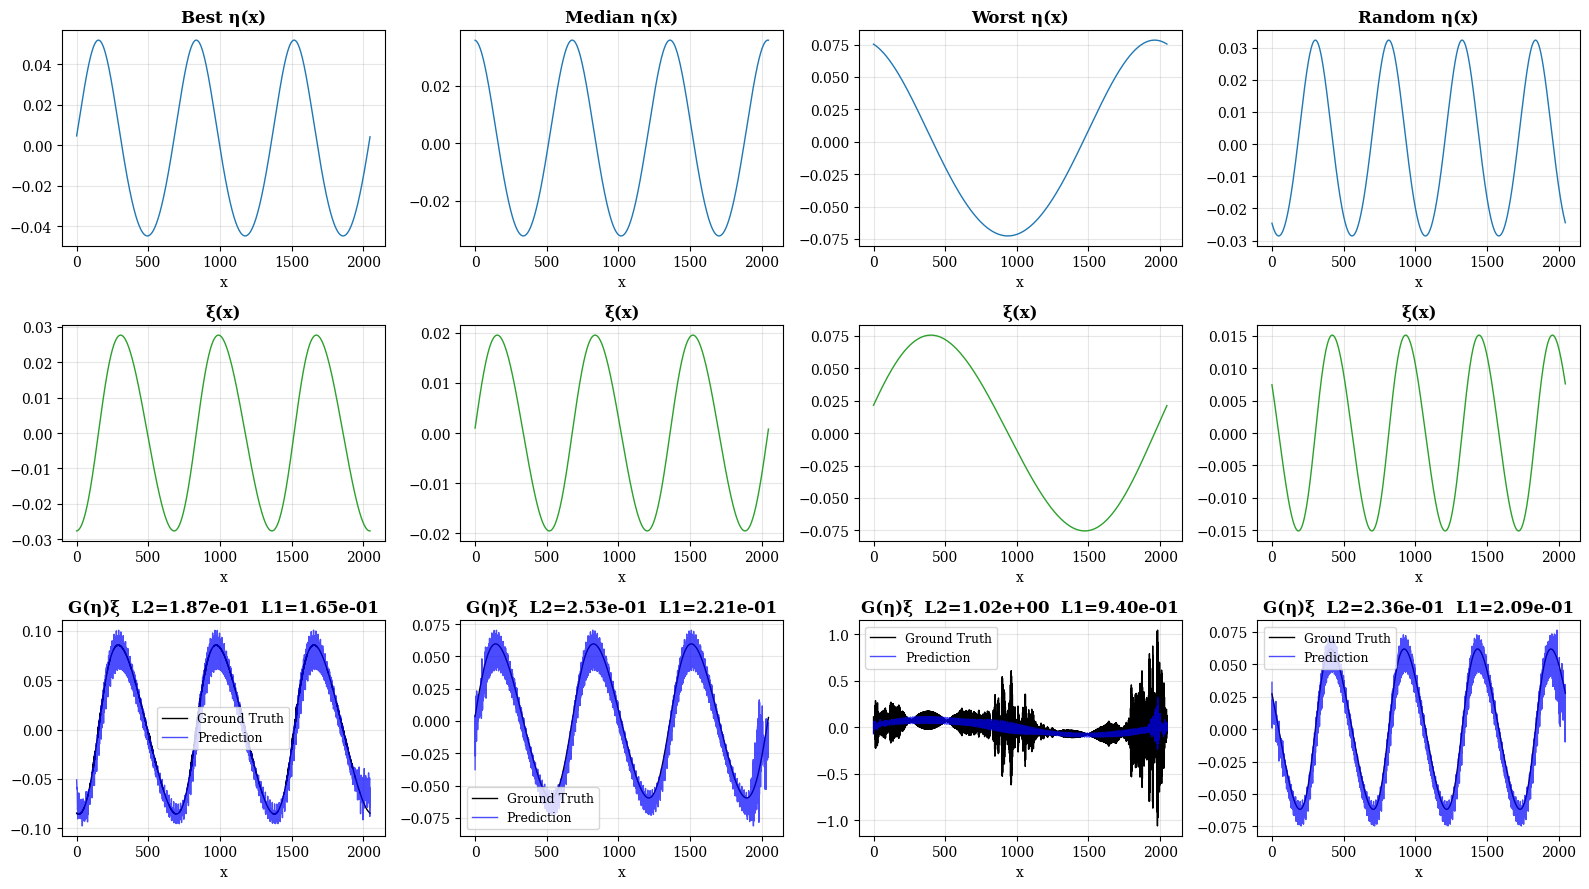

In [14]:
# Plot best / median / worst / random predictions
fig, axes = plt.subplots(3, 4, figsize=(16, 9))
order = ["best", "median", "worst", "random"]

for col, key in enumerate(order):
    idx = sample_indices[key]
    err_l2 = errors_l2[idx].item()
    err_l1 = errors_l1[idx].item()

    axes[0, col].plot(x_plot, eta_raw[idx].numpy(), color="tab:blue", linewidth=1.0)
    axes[0, col].set_title(f"{key.title()} η(x)", fontdict=title_font)
    axes[0, col].set_xlabel("x")
    axes[0, col].grid(True, alpha=0.3)

    axes[1, col].plot(x_plot, xi_raw[idx].numpy(), color="tab:green", linewidth=1.0)
    axes[1, col].set_title("ξ(x)", fontdict=title_font)
    axes[1, col].set_xlabel("x")
    axes[1, col].grid(True, alpha=0.3)

    axes[2, col].plot(x_plot, Gxi_raw[idx].numpy(), label="Ground Truth", color="black", linewidth=1.0)
    axes[2, col].plot(x_plot, predictions[idx].cpu().numpy(), label="Prediction", color="blue", linewidth=1.0, alpha=0.7)
    axes[2, col].set_title(f"G(η)ξ  L2={err_l2:.2e}  L1={err_l1:.2e}", fontdict=title_font)
    axes[2, col].set_xlabel("x")
    axes[2, col].grid(True, alpha=0.3)
    axes[2, col].legend(fontsize=9)

plt.tight_layout()
plt.show()

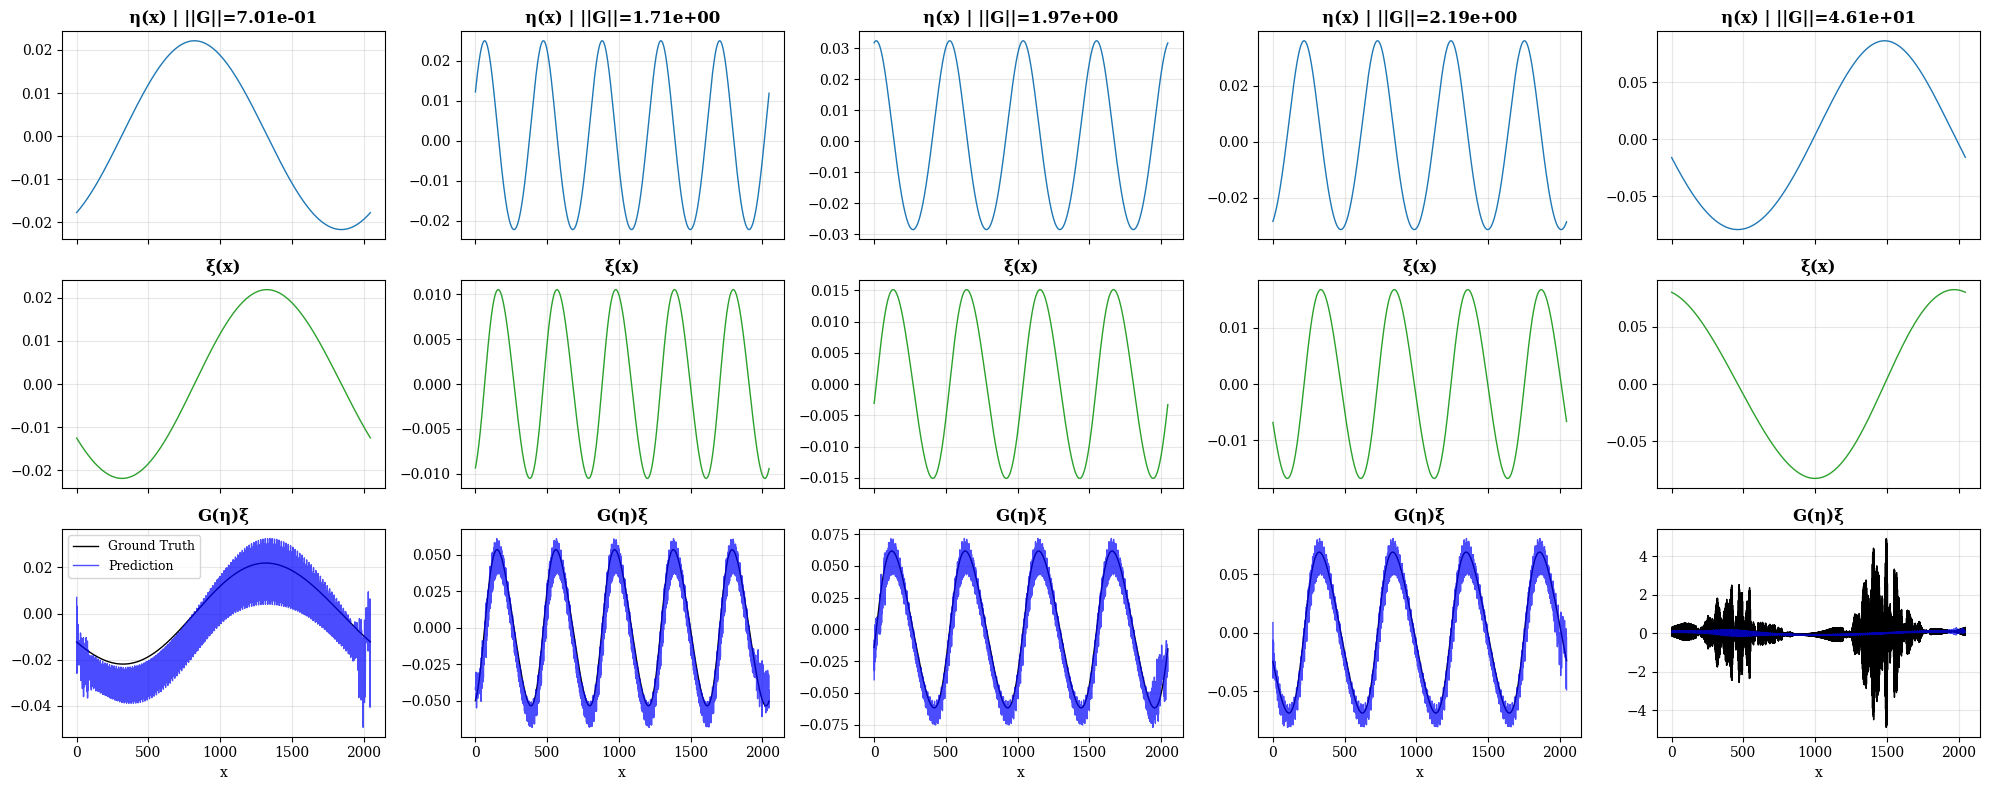

In [15]:
# Plot 5 test examples sorted by ||G(η)ξ|| (small -> large)
flat_norms = torch.norm(Gxi_raw.view(Gxi_raw.size(0), -1), dim=1)
sorted_by_norm = torch.argsort(flat_norms)

num_show = 5
sampled = torch.linspace(0, len(sorted_by_norm) - 1, num_show).long()
selected = sorted_by_norm[sampled]

fig, axes = plt.subplots(3, num_show, figsize=(4 * num_show, 8), sharex=True)
for col, idx in enumerate(selected.tolist()):
    axes[0, col].plot(x_plot, eta_raw[idx].numpy(), color="tab:blue", linewidth=1.0)
    axes[0, col].set_title(f"η(x) | ||G||={flat_norms[idx]:.2e}", fontdict=title_font)
    axes[0, col].grid(True, alpha=0.3)

    axes[1, col].plot(x_plot, xi_raw[idx].numpy(), color="tab:green", linewidth=1.0)
    axes[1, col].set_title("ξ(x)", fontdict=title_font)
    axes[1, col].grid(True, alpha=0.3)

    axes[2, col].plot(x_plot, Gxi_raw[idx].numpy(), label="Ground Truth", color="black", linewidth=1.0)
    axes[2, col].plot(x_plot, predictions[idx].cpu().numpy(), label="Prediction", color="blue", linewidth=1.0, alpha=0.7)
    axes[2, col].set_title("G(η)ξ", fontdict=title_font)
    axes[2, col].set_xlabel("x")
    axes[2, col].grid(True, alpha=0.3)
    if col == 0:
        axes[2, col].legend(fontsize=9)

plt.tight_layout()
plt.show()